# Credit Card Fraud Detection Analysis

**Module:** CMP7005 Programming for Data Analysis  
**Assessment:** PRAC1  
**Student ID:** st20357375  

## Objective
This notebook presents the full workflow for analysing credit card transaction data and developing machine learning models to identify fraudulent transactions. The work includes dataset merging, exploratory data analysis, preprocessing, model development, evaluation, and improvement.

## Dataset Summary
The analysis is based on two CSV files provided for the assignment. The target variable is binary, where:
- `1` indicates a fraudulent transaction
- `0` indicates a non-fraudulent transaction

The dataset is highly imbalanced, so model evaluation will focus on more than accuracy alone.


# 1. Setup and Library Import
This section imports the libraries required for data handling, visualisation, preprocessing, and machine learning.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

# Ensure screenshots directory exists
Path("../screenshots").mkdir(parents=True, exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


# 2. Task 1: Data Handling and Merging
## 2.1 Load the datasets
The two CSV files were loaded into pandas DataFrames for inspection and merging.


In [2]:
data_path = Path("../data")

df1 = pd.read_csv(data_path / "Credit_Card_Dataset_2025_Sept_1.csv")
df2 = pd.read_csv(data_path / "Credit_Card_Dataset_2025_Sept_2.csv")

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)


Dataset 1 shape: (25134, 17)
Dataset 2 shape: (25134, 4)


## 2.2 Inspect dataset structure
Before merging, both datasets were examined to confirm the available columns, data types, and the shared key.


In [3]:
print("Dataset 1 columns:")
print(df1.columns.tolist())

print("\nDataset 2 columns:")
print(df2.columns.tolist())


Dataset 1 columns:
['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET']

Dataset 2 columns:
['INCOME', 'INCOME_TYPE', 'User', 'EDUCATION_TYPE']


In [4]:
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      25134 non-null  int64  
 1   ID              25134 non-null  int64  
 2   GENDER          25134 non-null  object 
 3   CAR             25134 non-null  object 
 4   REALITY         25134 non-null  object 
 5   NO_OF_CHILD     25134 non-null  int64  
 6   FAMILY_TYPE     25134 non-null  object 
 7   HOUSE_TYPE      25134 non-null  object 
 8   FLAG_MOBIL      25134 non-null  int64  
 9   WORK_PHONE      25134 non-null  int64  
 10  PHONE           25134 non-null  int64  
 11  E_MAIL          25134 non-null  int64  
 12  FAMILY SIZE     25133 non-null  float64
 13  BEGIN_MONTH     25134 non-null  int64  
 14  AGE             25134 non-null  int64  
 15  YEARS_EMPLOYED  25125 non-null  float64
 16  TARGET          25134 non-null  int64  
dtypes: float64(2), int64(10), objec

In [5]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25134 entries, 0 to 25133
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   INCOME          25134 non-null  float64
 1   INCOME_TYPE     25122 non-null  object 
 2   User            25134 non-null  int64  
 3   EDUCATION_TYPE  25134 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 785.6+ KB


## 2.3 Merge the datasets
The datasets were merged using the common primary key `ID`. An inner join was used so that only matching records from both files were retained in the final dataset.


In [6]:
# Rename columns to standardise them across both datasets
df1.rename(columns={"TARGET": "Target"}, inplace=True)
df2.rename(columns={"User": "ID"}, inplace=True)

# Drop any accidental Unnamed index columns
df1 = df1.loc[:, ~df1.columns.str.contains("^Unnamed")]

# Merge the datasets
df = pd.merge(df1, df2, on="ID", how="inner")

print("Merged dataset shape:", df.shape)
df.head()


Merged dataset shape: (25134, 19)


,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,Target,INCOME,INCOME_TYPE,EDUCATION_TYPE
0,5008806,M,Y,Y,0,Married,House / apartment,1,0,0,0,2.0,29,59,3.0,0,112500.0,Working,Secondary / secondary special
1,5008808,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
2,5008809,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
3,5008810,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
4,5008811,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special


### Interpretation

The two datasets were successfully merged using the common primary key `ID`. Before merging, the `User` column in the second dataset was renamed to `ID` to ensure consistency across both files. The unnecessary `Unnamed: 0` column was removed from the first dataset, and `TARGET` was renamed to `Target` for clarity and standardisation.

An inner join was applied, ensuring that only matching records from both datasets were retained. The final merged dataset contains 25,134 rows and 19 columns, forming the main dataset used for all subsequent analysis.


# 3. Task 2a: Fundamental Data Understanding
## 3.1 Dataset structure and data types


In [7]:
print("Number of rows and columns:", df.shape)
print("\nData types:")
display(df.dtypes)


Number of rows and columns: (25134, 19)

Data types:


ID                  int64
GENDER             object
CAR                object
REALITY            object
NO_OF_CHILD         int64
FAMILY_TYPE        object
HOUSE_TYPE         object
FLAG_MOBIL          int64
WORK_PHONE          int64
PHONE               int64
E_MAIL              int64
FAMILY SIZE       float64
BEGIN_MONTH         int64
AGE                 int64
YEARS_EMPLOYED    float64
Target              int64
INCOME            float64
INCOME_TYPE        object
EDUCATION_TYPE     object
dtype: object

### Interpretation

The dataset contains 25,134 records and 19 features after merging. The data includes a mix of numerical and categorical variables. Numerical variables include age, income, and years employed, while categorical variables describe customer attributes such as gender, education level, and housing type. Understanding these data types is important for selecting appropriate preprocessing techniques later in the analysis.


## 3.2 Column summary and unique values


In [8]:
summary_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isnull().sum().values,
    "unique_values": df.nunique(dropna=False).values
})

summary_df


,column,dtype,missing_values,unique_values
0,ID,int64,0,25134
1,GENDER,object,0,2
2,CAR,object,0,2
3,REALITY,object,0,2
4,NO_OF_CHILD,int64,0,9
5,FAMILY_TYPE,object,0,5
6,HOUSE_TYPE,object,0,6
7,FLAG_MOBIL,int64,0,1
8,WORK_PHONE,int64,0,2
9,PHONE,int64,0,2


### Interpretation

The summary shows that most variables have a reasonable number of unique values. However, `FLAG_MOBIL` contains only one unique value, meaning it provides no useful variation for modelling. This will be addressed during preprocessing.

Some variables such as `INCOME` and `AGE` have wide ranges, which may indicate skewness or potential outliers that require further investigation.


## 3.3 Descriptive statistics


In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,25134.0,5.078838e+06,41941.018788,5008806.0,5042228.25,5079004.0,5115603.75,5150487.0
NO_OF_CHILD,25134.0,5.123339e-01,0.787785,0.0,0.00,0.0,1.00,19.0
FLAG_MOBIL,25134.0,1.000000e+00,0.000000,1.0,1.00,1.0,1.00,1.0
WORK_PHONE,25134.0,2.738124e-01,0.445923,0.0,0.00,0.0,1.00,1.0
PHONE,25134.0,2.927906e-01,0.455052,0.0,0.00,0.0,1.00,1.0
E_MAIL,25134.0,1.006605e-01,0.300885,0.0,0.00,0.0,0.00,1.0
FAMILY SIZE,25133.0,2.294076e+00,0.947607,1.0,2.00,2.0,3.00,20.0
BEGIN_MONTH,25134.0,2.612059e+01,16.439658,0.0,12.00,24.0,39.00,60.0
AGE,25134.0,4.059000e+01,10.348136,21.0,33.00,40.0,48.00,450.0
YEARS_EMPLOYED,25125.0,7.205214e+00,6.415004,0.0,3.00,5.0,10.00,43.0


### Interpretation

The descriptive statistics show that `INCOME` is highly skewed with a wide range of values, suggesting the presence of high-income outliers. The `AGE` variable contains an unrealistic maximum value of 450, indicating possible data entry errors. These extreme values will be reviewed during outlier analysis rather than removed automatically.

The dataset also shows variation in employment duration and family size, which may influence fraud behaviour.


## 3.4 Missing value analysis


In [10]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
missing_values


INCOME_TYPE       12
YEARS_EMPLOYED     9
FAMILY SIZE        1
dtype: int64

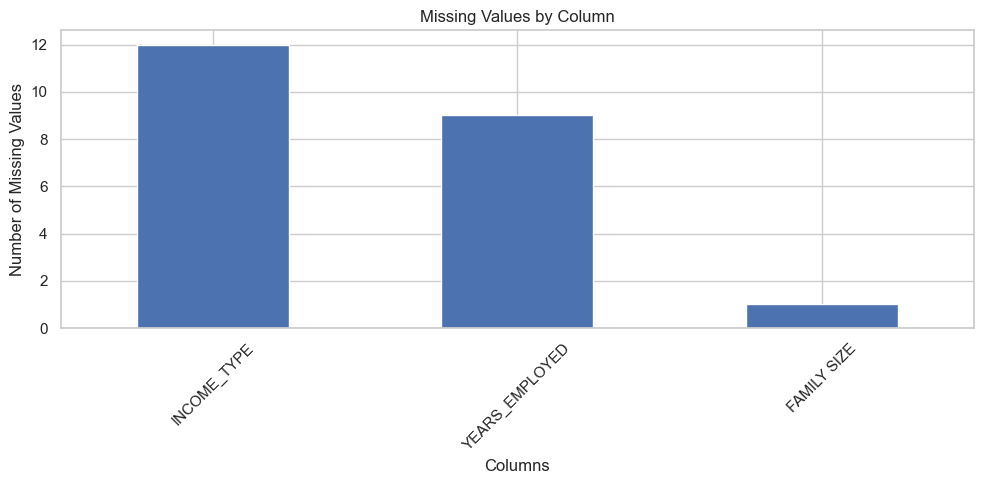

In [11]:
plt.figure(figsize=(10, 5))
missing_values.plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../screenshots/task2_missing_values.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

Only a small number of missing values are present in `INCOME_TYPE`, `YEARS_EMPLOYED`, and `FAMILY SIZE`. Since the proportion of missing data is very low, simple imputation strategies such as median (for numerical variables) and most frequent value (for categorical variables) are appropriate.


## 3.5 Target variable distribution


In [12]:
target_counts = df["Target"].value_counts()
target_percent = df["Target"].value_counts(normalize=True) * 100

print(target_counts)
print("\nPercentage distribution:")
print(target_percent.round(2))


Target
0    24712
1      422
Name: count, dtype: int64

Percentage distribution:
Target
0    98.32
1     1.68
Name: proportion, dtype: float64


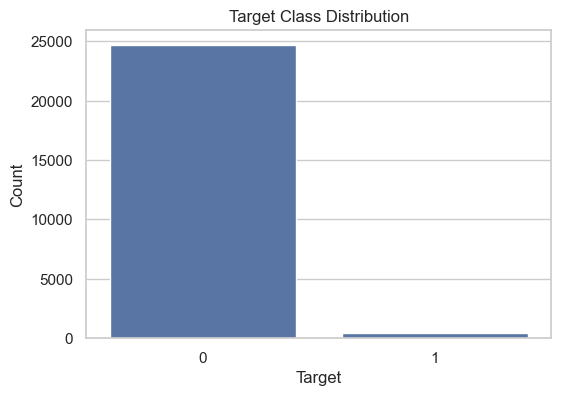

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Target")
plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.savefig("../screenshots/task2_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

The class distribution confirms a severe imbalance, with only 1.68% fraudulent cases. This justifies the use of recall and F1-score as priority metrics during model evaluation. A model can achieve high accuracy by predicting most cases as non-fraud, since almost all transactions are legitimate. Therefore, accuracy alone is misleading; recall matters because missing fraud is costly, and precision matters because too many false alarms are also a problem.


### Summary of Fundamental Findings

The initial review of the merged dataset revealed four key issues. First, the target variable is highly imbalanced, with only 1.68% fraudulent cases. Second, missing values are limited to a small number of records in three variables. Third, `FLAG_MOBIL` has no variation and is therefore unlikely to be useful for modelling. Finally, `AGE` contains at least one unrealistic value, indicating a small amount of abnormal data that should be considered during preprocessing.


# 4. Task 2b: Data Preprocessing
## 4.1 Duplicate check


In [14]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Shape after removing duplicates: (25134, 19)


## 4.2 Removal of non-informative features


In [15]:
df = df.drop(columns=["FLAG_MOBIL"])


### Interpretation

The `FLAG_MOBIL` variable was removed because it contains only one unique value across all records and therefore provides no predictive information for modelling.


## 4.3 Feature selection and separation


In [16]:
# ID is removed because it is only an identifier and has no predictive meaning.
X = df.drop(columns=["Target", "ID"])
y = df["Target"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['GENDER', 'CAR', 'REALITY', 'FAMILY_TYPE', 'HOUSE_TYPE', 'INCOME_TYPE', 'EDUCATION_TYPE']
Numerical columns: ['NO_OF_CHILD', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'INCOME']


### Interpretation

The `ID` column was removed as it is only an identifier and does not carry predictive value. The dataset was then divided into categorical and numerical features to prepare for appropriate preprocessing steps.


## 4.4 Category review


In [17]:
for col in ['INCOME_TYPE', 'EDUCATION_TYPE', 'FAMILY_TYPE']:
    print(f"\nValue Counts for {col}:")
    print(X[col].value_counts(normalize=True).round(3))



Value Counts for INCOME_TYPE:
INCOME_TYPE
Working                 0.622
Commercial associate    0.281
State servant           0.097
Pensioner               0.001
Student                 0.000
Name: proportion, dtype: float64

Value Counts for EDUCATION_TYPE:
EDUCATION_TYPE
Secondary / secondary special    0.669
Higher education                 0.284
Incomplete higher                0.040
Lower secondary                  0.007
Academic degree                  0.001
Name: proportion, dtype: float64

Value Counts for FAMILY_TYPE:
FAMILY_TYPE
Married                 0.697
Single / not married    0.137
Civil marriage          0.085
Separated               0.058
Widow                   0.023
Name: proportion, dtype: float64


### Interpretation

The category review shows that the dataset is dominated by customers with `Working` income type, `Secondary / secondary special` education, and `Married` family status. This helps establish the overall customer profile and highlights that some categories, such as `Student` and `Academic degree`, are very rare and may have limited predictive influence.


## 4.5 Outlier inspection


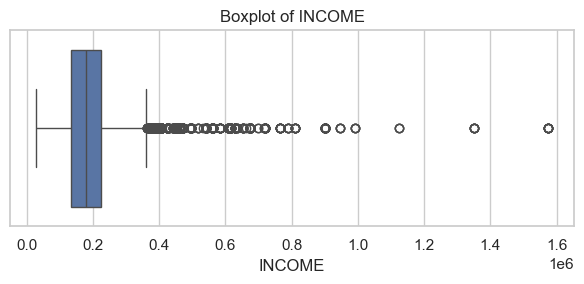

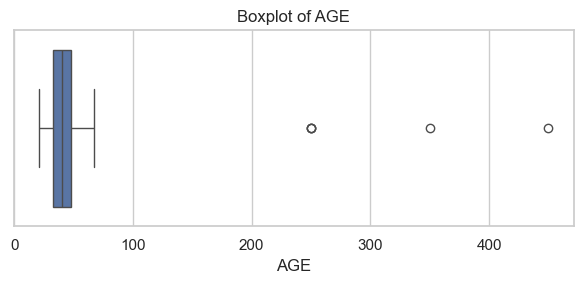

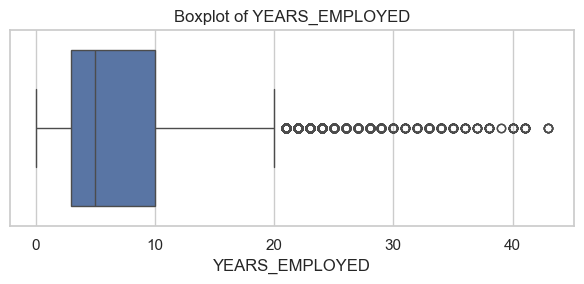

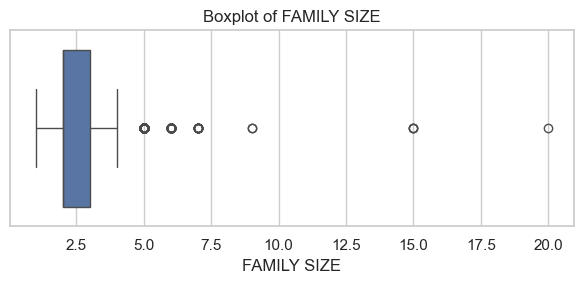

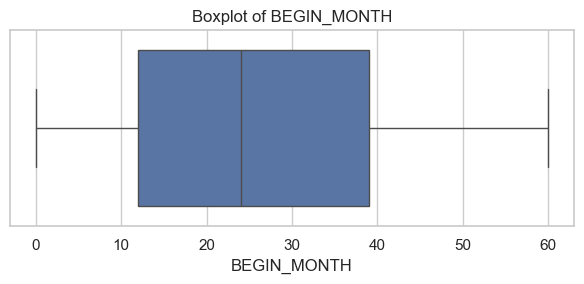

In [18]:
outlier_cols = ["INCOME", "AGE", "YEARS_EMPLOYED", "FAMILY SIZE", "BEGIN_MONTH"]

for col in outlier_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


### Interpretation

The boxplots confirm that `INCOME` contains several high-value outliers, which is expected in financial data and does not automatically indicate an error. However, the `AGE` variable includes at least one clearly unrealistic value, and household-related variables such as `FAMILY SIZE` also contain extreme values. These values were retained because they may reflect rare but valid cases, although they are acknowledged as a limitation of the dataset.


## 4.6 Preprocessing strategy
### Preprocessing Strategy

For model preparation, missing numerical values will be imputed using the median, while categorical values will be imputed using the most frequent category. Categorical variables will be encoded using one-hot encoding, and numerical variables will be scaled where required. These steps will be defined at this stage and later implemented through a modelling pipeline to ensure consistency and avoid data leakage.


# 5. Task 2c: Statistical Analysis and Visualisation
## 5.1 Univariate analysis


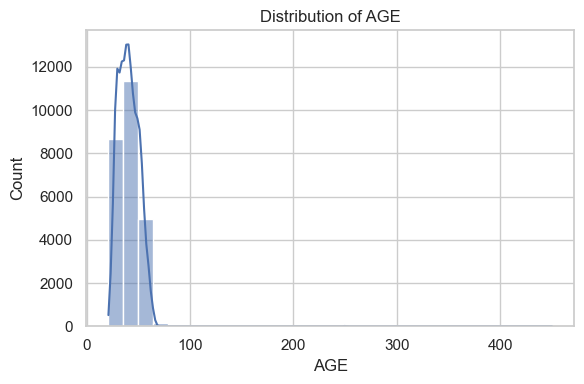

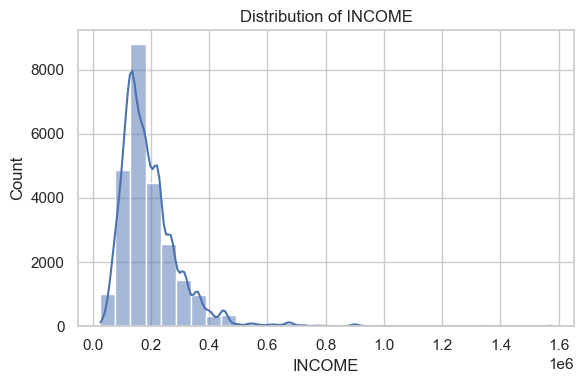

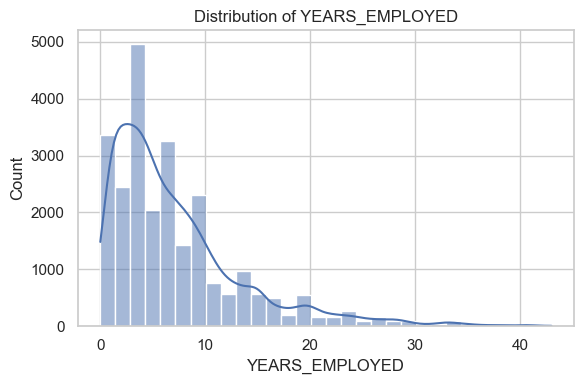

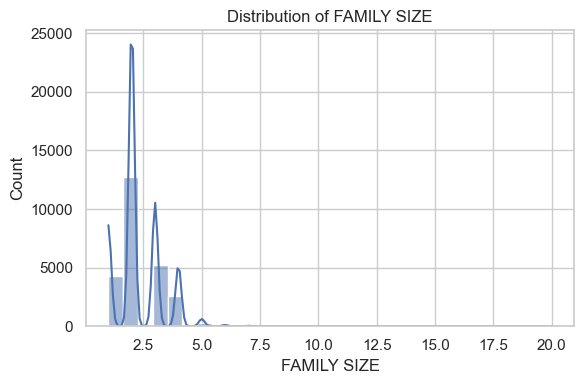

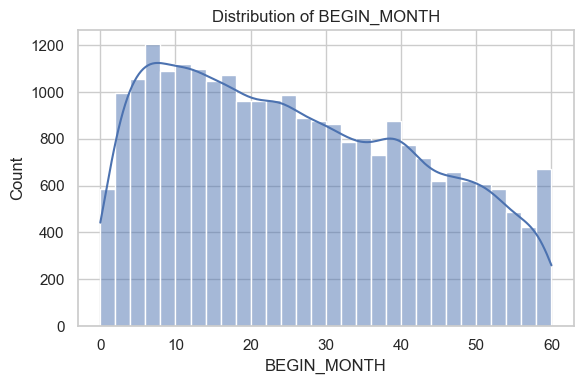

In [19]:
univariate_num = ["AGE", "INCOME", "YEARS_EMPLOYED", "FAMILY SIZE", "BEGIN_MONTH"]

for col in univariate_num:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    if col == "INCOME":
        plt.savefig("../screenshots/task2_income_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()


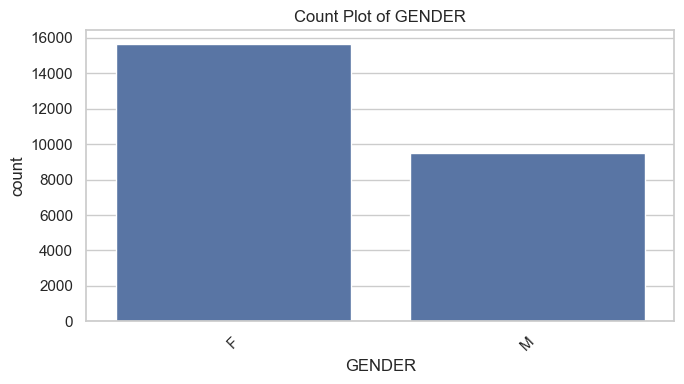

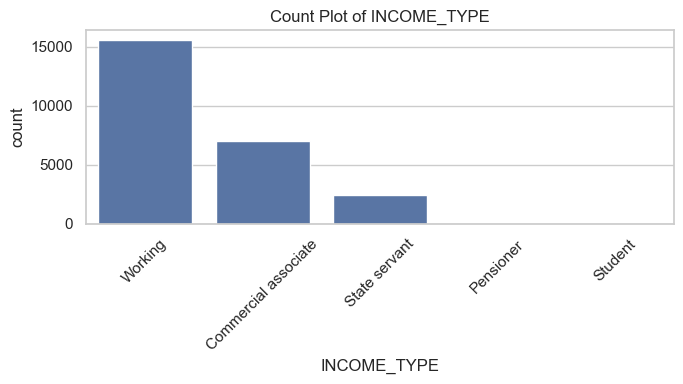

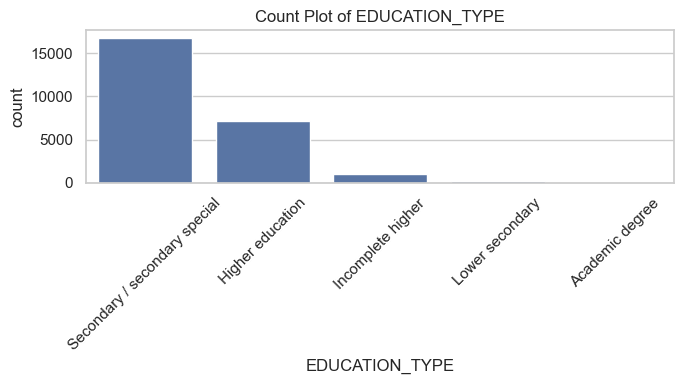

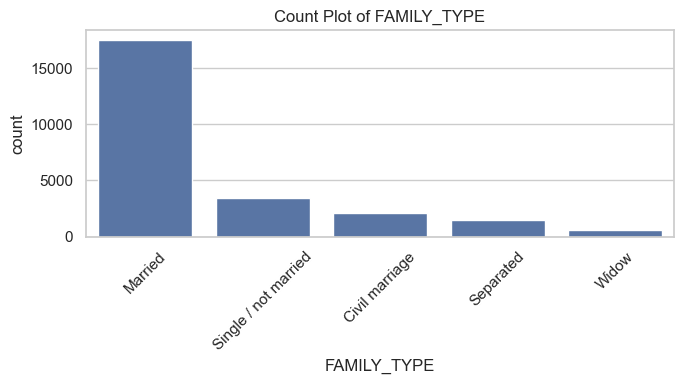

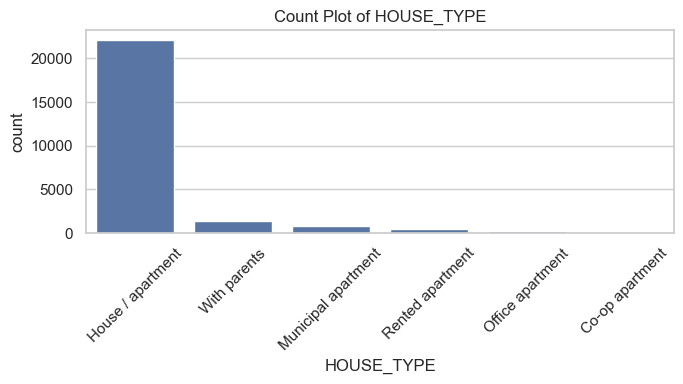

In [20]:
univariate_cat = ["GENDER", "INCOME_TYPE", "EDUCATION_TYPE", "FAMILY_TYPE", "HOUSE_TYPE"]

for col in univariate_cat:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Interpretation

The univariate plots show that `INCOME` is strongly right-skewed, confirming that a small number of customers have much higher income than the majority. `AGE` and `YEARS_EMPLOYED` appear more concentrated around middle ranges, while `BEGIN_MONTH` is distributed across the 60-month observation period. Among categorical variables, `House / apartment`, `Working`, and `Secondary / secondary special` are the dominant categories, indicating the most common customer profiles in the dataset.


## 5.2 Bivariate analysis


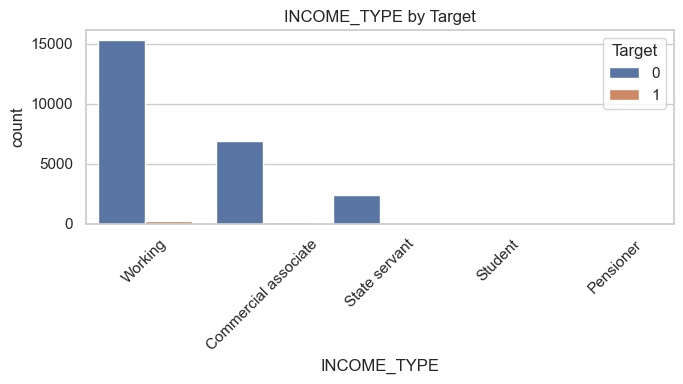

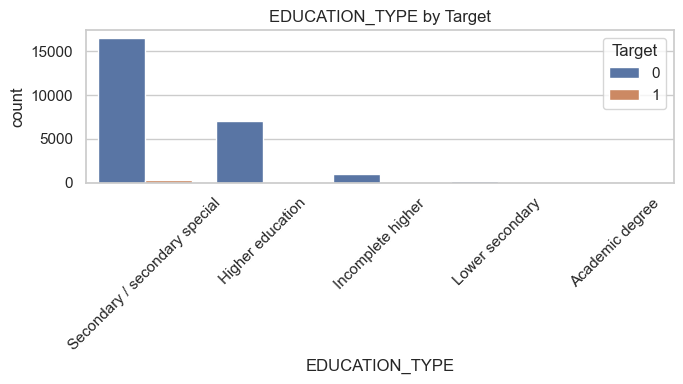

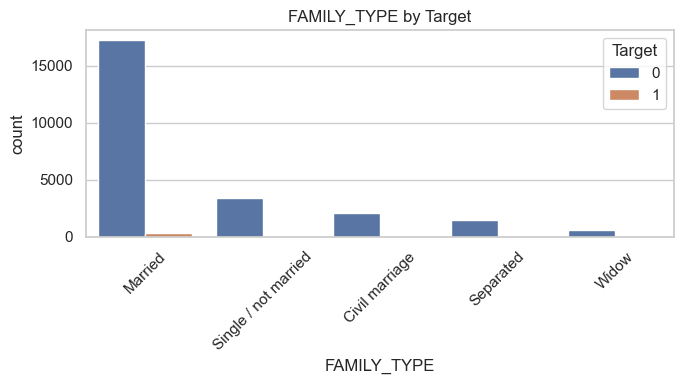

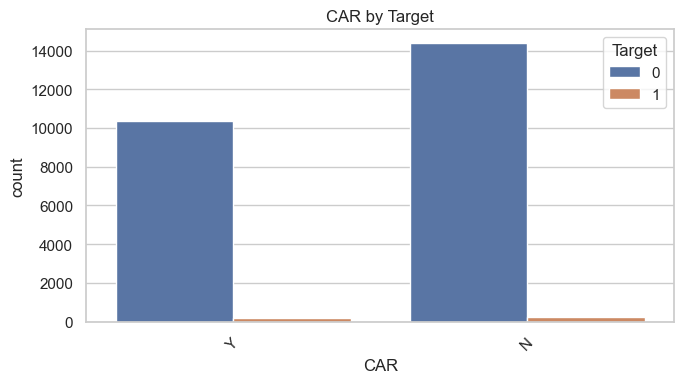

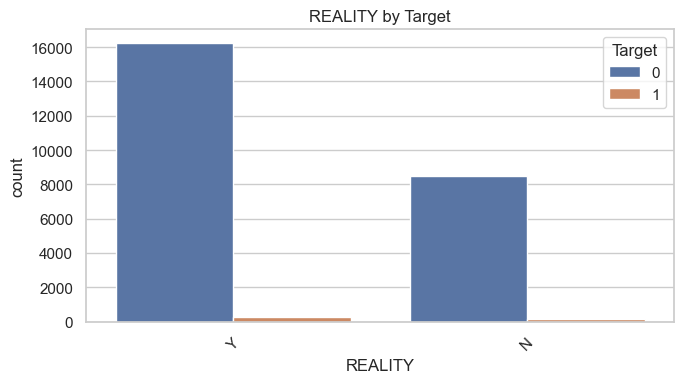

In [21]:
bivariate_cat = ["INCOME_TYPE", "EDUCATION_TYPE", "FAMILY_TYPE", "CAR", "REALITY"]

for col in bivariate_cat:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue="Target")
    plt.title(f"{col} by Target")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


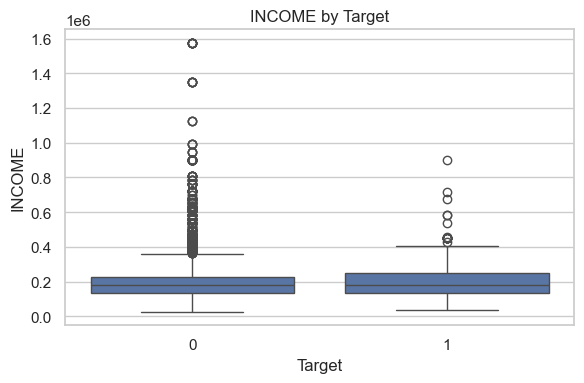

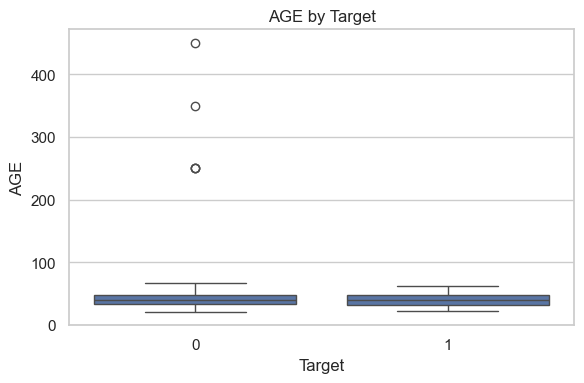

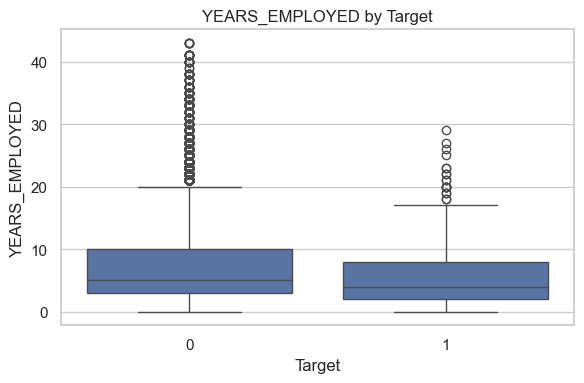

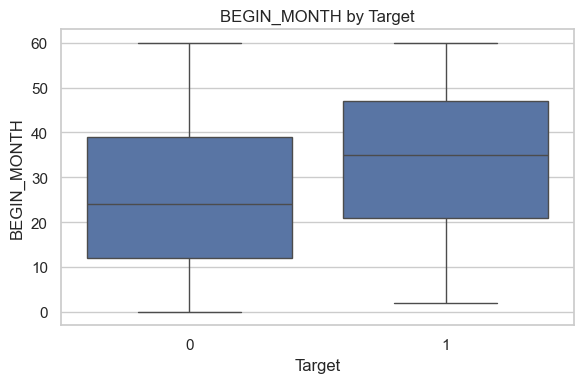

In [22]:
bivariate_num = ["INCOME", "AGE", "YEARS_EMPLOYED", "BEGIN_MONTH"]

for col in bivariate_num:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Target", y=col)
    plt.title(f"{col} by Target")
    plt.tight_layout()
    plt.show()


### Interpretation

The bivariate analysis suggests that fraud patterns are not driven by a single variable. Some categorical groups appear to contain more fraud cases, but this is influenced by the size of each category. The boxplots show that fraudulent cases tend to have slightly different distributions for `INCOME`, `AGE`, and especially `YEARS_EMPLOYED`, where fraudulent cases appear to have lower employment duration on average. These observations suggest that fraud risk may be influenced by a combination of demographic and financial characteristics.


In [23]:
df.groupby("Target")[["INCOME", "AGE", "YEARS_EMPLOYED", "FAMILY SIZE"]].mean()

,INCOME,AGE,YEARS_EMPLOYED,FAMILY SIZE
Target,,,,
0,194744.671738,40.600761,7.232052,2.294768
1,200056.148104,39.959716,5.607229,2.253555


### Interpretation

The grouped summary highlights measurable differences between fraudulent and non-fraudulent transactions. Fraudulent cases have a higher average income, a slightly lower average age, and notably fewer years of employment compared to non-fraudulent cases. The difference in family size is minimal.

These findings suggest that employment duration and income may play a meaningful role in distinguishing fraudulent behaviour. While these differences do not imply causation, they provide useful signals that can be leveraged during model development.


## 5.3 Fraud-rate by category


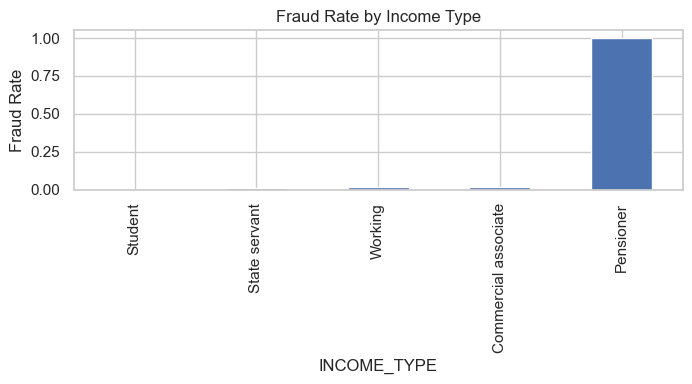

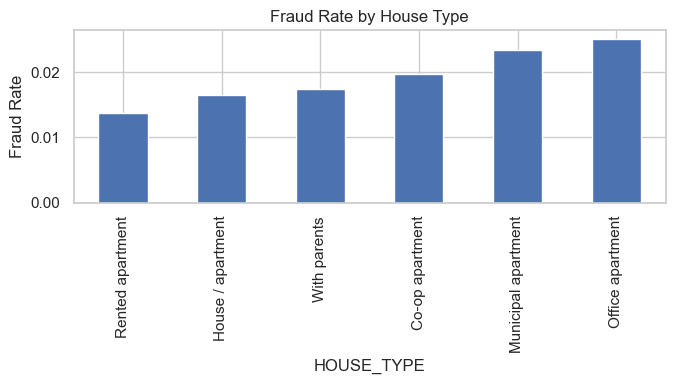

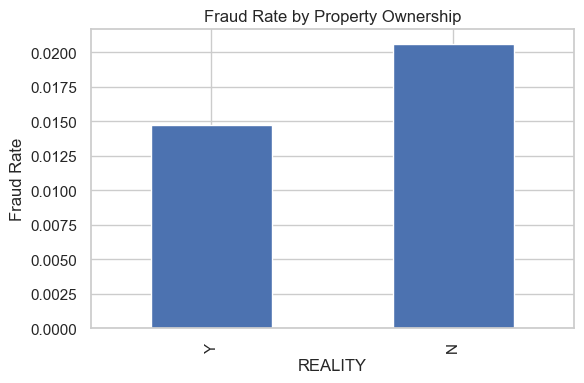

In [24]:
fraud_rate_income = df.groupby("INCOME_TYPE")["Target"].mean().sort_values()

plt.figure(figsize=(7,4))
fraud_rate_income.plot(kind="bar")
plt.title("Fraud Rate by Income Type")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.savefig("../screenshots/task2_fraud_rate_income.png", dpi=300)
plt.show()

fraud_rate_house = df.groupby("HOUSE_TYPE")["Target"].mean().sort_values()

plt.figure(figsize=(7,4))
fraud_rate_house.plot(kind="bar")
plt.title("Fraud Rate by House Type")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

fraud_rate_reality = df.groupby("REALITY")["Target"].mean().sort_values()

plt.figure(figsize=(6,4))
fraud_rate_reality.plot(kind="bar")
plt.title("Fraud Rate by Property Ownership")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.savefig("../screenshots/task2_fraud_rate_reality.png", dpi=300)
plt.show()


### Interpretation

Fraud-rate analysis provides a clearer view of relative risk than raw count plots in an imbalanced dataset. The results suggest that fraud proportions vary across income types, housing conditions, and property ownership status. This indicates that these categorical features may contribute useful signal during model development, even when raw fraud counts appear small.


## 5.4 Multivariate analysis


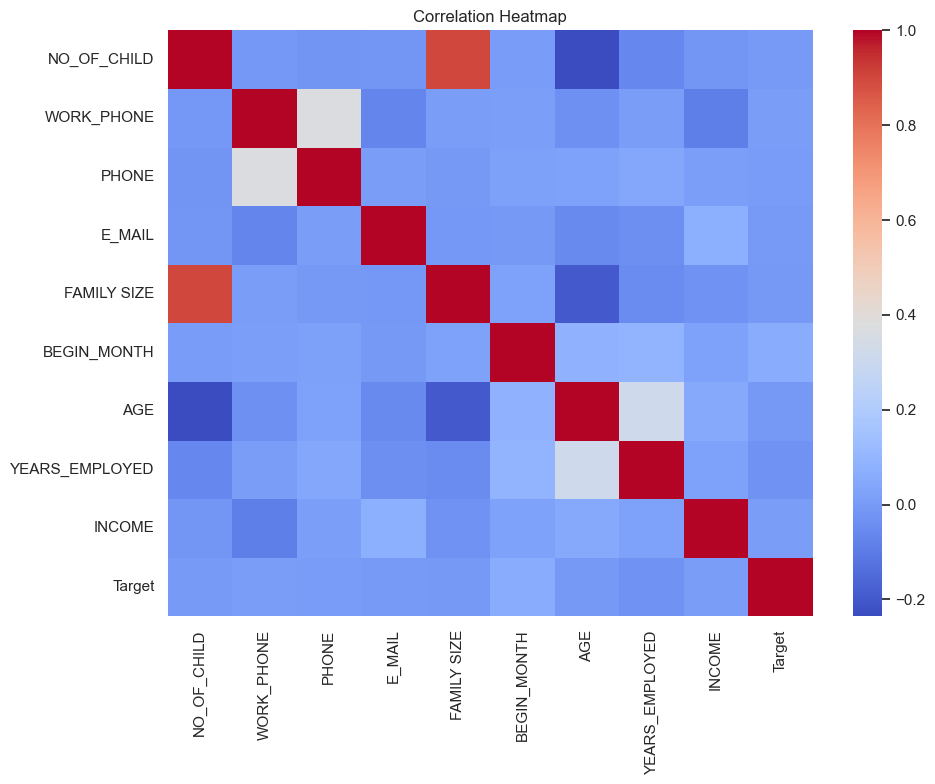

In [25]:
corr = df[numerical_cols + ["Target"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../screenshots/task2_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

The correlation heatmap shows that no single numerical feature has a strong linear relationship with the target variable. This suggests that fraud detection in this dataset is unlikely to depend on one dominant predictor alone. Instead, the target is influenced by a combination of variables, which supports the use of machine learning models capable of capturing complex relationships rather than relying on simple linear assumptions.


# 6. Task 3: Model Building and Evaluation

## 6.1 Train-test split

The dataset was split into training and test sets. Stratified sampling was used to preserve the class imbalance distribution in both sets.


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (20107, 16)
Test set shape: (5027, 16)


## 6.2 Preprocessing pipeline

To ensure consistency and avoid data leakage, preprocessing steps were applied using a pipeline.

- Numerical features: imputed using median and scaled
- Categorical features: imputed using most frequent value and one-hot encoded

This preprocessing is applied consistently across all models.


In [27]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])


## 6.3 Candidate model selection

Five classification models were selected to evaluate different learning approaches:

- Logistic Regression (linear baseline)
- Decision Tree (simple non-linear model)
- Random Forest (ensemble model)
- Gradient Boosting (boosting-based ensemble)
- AdaBoost (adaptive boosting method)

These models were chosen to provide a balance between interpretability and predictive power.


In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}


## 6.4 Baseline model training and evaluation

Each model was trained using the same preprocessing pipeline and evaluated on the test dataset using accuracy, precision, recall, and F1-score.


In [29]:
results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T.round(4)
results_df


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.6376,0.0303,0.6667,0.0579
Decision Tree,0.9694,0.1500,0.1786,0.1630
Random Forest,0.9823,0.4074,0.1310,0.1982
Gradient Boosting,0.9831,0.4286,0.0357,0.0659
AdaBoost,0.9839,1.0000,0.0357,0.0690


## 6.5 Comparison of candidate models

The models were compared using multiple evaluation metrics. In an imbalanced dataset, recall and F1-score are more important than accuracy alone.


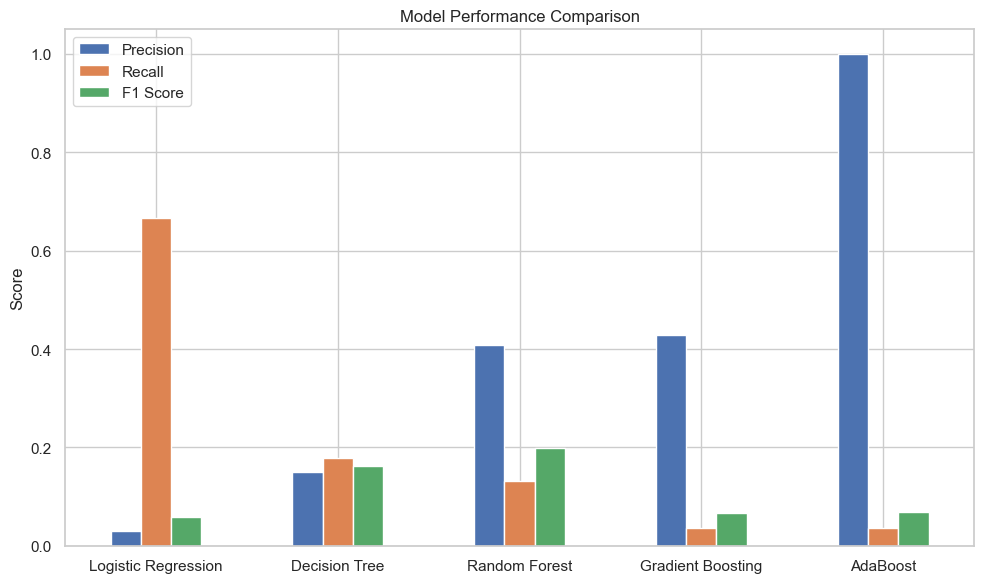

In [30]:
results_df[["Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../screenshots/task3_model_comparison.png", dpi=300)
plt.show()


### Interpretation

The results show clear differences between models. Logistic Regression achieves higher recall but very low precision, meaning it detects more fraud but produces many false positives. Tree-based models such as Random Forest and Gradient Boosting provide better balance between precision and recall.

This difference highlights the trade-off between detecting fraud (recall) and avoiding false alarms (precision). In fraud detection, missing fraudulent transactions is costly, so recall is an important metric, but precision must also be considered.


## 6.6 Selection of best models

Based on overall performance, the two best models were selected for further consideration:

- Random Forest
- Gradient Boosting

These models demonstrated a better balance between precision and recall compared to others.


## 6.7 Model improvement using SMOTE

To address class imbalance, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data. This increases the representation of fraudulent cases and improves model learning.


In [31]:
# Preprocess first
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

# Train improved model
rf_improved = RandomForestClassifier(n_estimators=300, random_state=42)
rf_improved.fit(X_train_smote, y_train_smote)

y_pred_rf_improved = rf_improved.predict(X_test_processed)

rf_improved_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf_improved),
    "Precision": precision_score(y_test, y_pred_rf_improved),
    "Recall": recall_score(y_test, y_pred_rf_improved),
    "F1 Score": f1_score(y_test, y_pred_rf_improved)
}

pd.DataFrame(rf_improved_results, index=["Improved Random Forest"]).round(4)


,Accuracy,Precision,Recall,F1 Score
Improved Random Forest,0.9815,0.4,0.2143,0.2791


## 6.8 Final model selection

The Improved Random Forest model was selected as the final model. Although its accuracy is slightly lower than the baseline Random Forest, it achieves higher recall and F1-score, making it more suitable for detecting fraudulent transactions in an imbalanced dataset.


## 6.9 Saving trained models

The trained models and preprocessing pipeline were saved using joblib to allow reuse in application development without retraining.


In [32]:
model_dir = Path("../app/models")
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(preprocessor, model_dir / "preprocessor.pkl")
joblib.dump(rf_improved, model_dir / "model_random_forest_smote.pkl")

print("Final model saved successfully.")


Final model saved successfully.


# 7. Conclusion
This notebook presented a complete workflow for credit card fraud detection using data analysis and machine learning. 

We refined our data by removing non-predictive variables `ID` and `FLAG_MOBIL`. The datasets were examined, cleaned, and analysed using insightful bivariate and grouped summaries. After addressing feature imbalances, five initial classification models were evaluated. Recognizing the trade-offs across different algorithms, SMOTE was introduced to improve the performance of the most promising candidate. 

Among the tested models, the *Improved Random Forest* was selected as the preferred candidate because it provided the best balance between recall and precision, resulting in the highest F1-score while retaining strong overall accuracy.

Finally, preprocessing pipelines and the selected model were saved appropriately, demonstrating professional model persistence for integration into deployment environments like FastAPI.
